# Ordering Planet Imagery


This tutorial uses [Planet](https://www.planet.com)'s Data and Orders API using the official [Python client](https://github.com/planetlabs/planet-client-python), the `planet` module. We will search for imagery while filtering for clouds based on a specific AOI.

## Requirements

This tutorial assumes familiarity with the [Python](https://python.org) programming language throughout. Python modules used in this tutorial are:
* [IPython](https://ipython.org/) and [Jupyter](https://jupyter.org/)
* [planet](https://github.com/planetlabs/planet-client-python)
* [geojsonio](https://pypi.python.org/pypi/geojsonio)
* [rasterio](https://rasterio.readthedocs.io/en/latest/index.html)
* [shapely](https://shapely.readthedocs.io/en/stable/index.html)
* [asyncio](https://docs.python.org/3/library/asyncio.html)

You should also have an account on the Planet Platform and retrieve your API key from your [account page](https://www.planet.com/account/).

## Useful links 
* [Planet Client V2 Documentation](https://github.com/planetlabs/planet-client-python)
* [Planet Data API reference](https://developers.planet.com/docs/apis/data/)

## Set up

In order to interact with the Planet API using the client, we need to import the necessary packages & define helper functions.

In [13]:
#general packages
import os
import os
import pytz

import json
import pathlib
from datetime import datetime
from collections import Counter
import datetime
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import pandas as pd
from datetime import datetime
from dateutil import parser
from collections import defaultdict
import requests
from shapely.geometry import shape, mapping
from shapely.ops import unary_union
from dotenv import load_dotenv

load_dotenv()

# We will also create a small helper function to print out JSON with proper indentation.
def indent(data):
    print(json.dumps(data, indent=2))

We next need to create a `client` object registered with our API key. The API key will be automatically read from the `PL_API_KEY` environment variable if it exists. You can also authenticate via the CLI using [`auth init`](https://planet-sdk-for-python-v2.readthedocs.io/en/latest/cli/cli-reference/?h=auth#auth:~:text=message%20and%20exit.-,auth,-%C2%B6), this will store your API key as an environment variable.

In [14]:
# if your Planet API Key is not set as an environment variable, you can paste it below
API_KEY = os.getenv('PL_API_KEY', '')

    # construct auth tuple for use in the requests library
BASIC_AUTH = (API_KEY, '')

## Searching for available imagery

We can search for items that are interesting by using the `quick_search` member function. Searches, however, always require a proper request that includes a filter that selects the specific items to return as seach results.

Let's also read in a GeoJSON geometry into a variable so we can use it during testing. The geometry can only have one polygon to work with the data API

In [15]:
with open("user_inputs/Tuktoyaktuk.geojson") as f:
    geom_all = json.loads(f.read())['features'][0]['geometry']  

# Setup Planet Data API base URL
URL = "https://api.planet.com/data/v1/quick-search"
print(geom_all)
# Setup the session
session = requests.Session()

# Authenticate
session.auth = (API_KEY, "")

{'type': 'Polygon', 'coordinates': [[[-133.0067709712898, 69.5372835366888], [-133.0714017534617, 69.43700277399775], [-133.3108298381294, 69.38577940515069], [-133.3107736398329, 69.3737386034634], [-132.9729923472225, 69.38867435373463], [-132.9110307044494, 69.47250999458548], [-132.9496617716011, 69.53813877788635], [-133.0067709712898, 69.5372835366888]]]}


### Filters

The possible filters include `and_filter`, `date_range_filter`, `range_filter` and so on, mirroring the options supported by the Planet API. Additional filters are described [here](https://planet-sdk-for-python-v2.readthedocs.io/en/latest/python/sdk-guide/#filter:~:text=(main())-,Filter,-%C2%B6).

In [16]:
# Define the filters we'll use to find our data
item_types = ["PSScene"]
#Date range filter
start_date = "2011-01-01T00:00:00.000Z"
end_date = "2026-12-31T00:00:00.000Z"

#Cloud cover filter
clear_percent =  60

#String filter for available asset
asset_type = "ortho_analytic_4b"

# Setup the request
request = {
    "item_types": item_types,
    "filter": {
        'type': 'AndFilter',
        'config': [
            {
                'type': 'GeometryFilter',
                'field_name': 'geometry',
                'config': geom_all
            },
            {
                'type': 'RangeFilter',
                'field_name': 'clear_percent',
                'config': {'gt': clear_percent}
            },
            {
                'type': 'AssetFilter',
                'config': [asset_type]
            },
            {
                'type': 'DateRangeFilter',
                'field_name': 'acquired',
                'config': {'gte': start_date, 'lte': end_date}
            }
        ]
    }
}
 

Now let's send the request, returning the first 250 results

In [17]:
# Send the POST request to the API quick search endpoint
res = session.post(URL, json=request)
# Assign the response to a variable
results = res.json()["features"]



To get the rest of the results you must paginate using the `_next` link. Printing out the number of available images within your AOI and TOI with greater then 60% clear pixels

In [18]:
next_url = res.json()['_links']['_next']

while next_url:
    next_features = session.get(next_url)
    results.extend(next_features.json()['features'])
    try:
        next_url = next_features.json()['_links']['_next']
    except:
        next_url = None

print(f"Total results: {len(results)}")



Total results: 1403


## AOI coverage filtering

First stage is to group all of the imagery by day

In [19]:
grouped = defaultdict(list)

for item in results:
    # Extract the ISO 8601 date-time string
    acquired_time = item["properties"]["acquired"]
    # Parse out just the date portion
    date_str = acquired_time.split("T")[0]

    grouped[date_str].append(item)

print("Days of imagery:", len(grouped.keys()))


Days of imagery: 315


Next compare the daily image coverage with your AOI, filtering out any day with lass coverage then the desired threshold

In [20]:
aoi_coverage_threshold = 0.99


# Convert the GeoJSON geometry to a shapely geometry object
aoi_geom = shape(geom_all)
geom_area = aoi_geom.area
print("Geom Area: " + str(geom_area))

valid_days = {}
merged_features = []

for day, items in grouped.items():
    shapely_geoms = []
    for meta in items:
        if 'geometry' in meta:
            shapely_geoms.append(shape(meta['geometry']))
    if not shapely_geoms:
        print(f"No valid geometries for {day}")
        continue

    merged_geom = unary_union(shapely_geoms)
    intersection_area = merged_geom.intersection(aoi_geom).area
    overlap_ratio = intersection_area / geom_area

    if overlap_ratio >= aoi_coverage_threshold:
        valid_days[day] = items
        merged_features.append({
            "type": "Feature",
            "properties": {
                "day": day,
                "overlap_ratio": overlap_ratio
            },
            "geometry": mapping(merged_geom.intersection(aoi_geom))
        })

print(f"Days passing {aoi_coverage_threshold*100}% overlap criterion:", len(valid_days.keys()))

merged_collection = {
    "type": "FeatureCollection",
    "features": merged_features
}

with open("merged_geoms.geojson", "w") as f:
    json.dump(merged_collection, f)

Geom Area: 0.0247465405621348
Days passing 99.0% overlap criterion: 140


Aggregate all of the days together into a set of Image IDs

In [21]:
valid_IDs = []
for day, items in valid_days.items():
    for item in items:
        valid_IDs.append(item['id'])

print("Number of valid IDs: ", len(valid_IDs))

Number of valid IDs:  903


## AOI based cloud filtering
The data api searches based on scene wide cloud statistics which means that a scene that is occasionally 60% clear might have clouds covering most of your AOI. We can do AOI level cloud filtering but it takes a bit longer so its good to filter down first with a normal data API call.

In [22]:
def create_cloud_filter_request(item_id):
    url = f"https://api.planet.com/data/v1/item-types/PSScene/items/{item_id}/coverage"
    headers = {
        "Content-Type": "application/json"
    }
    data = {
        "geometry": geom_all
    }

    return requests.post(url, headers=headers, json=data, auth=(API_KEY, ""))
    

In [23]:
item_cloud = {}

Itterate over all of the images found using the data API, making a request for AOI based cloud cover.

Could cover requests take about 10 min to be processed on Planets side. The first time running will place the request and once activated the request will return a cloud cover value. Placing the request for 300 images takes approximately 10 min. 

Problematic files that do not get a 200 code will be stored in the problematic dictionary and can be delt with on a case by case basis.

Rerun this code again until there are no more files in the activated stage

In [28]:
# For 500 images this took 20 minutes
i = 1
total_files = len(valid_IDs)
problematic = {}
for item_id in valid_IDs:

    print(f"Processing file {i}/{total_files}", end="\r") 
    if item_id not in item_cloud:
        request = create_cloud_filter_request(item_id)
        if request.status_code == 200:
            item_cloud[item_id] = request
        else:
            problematic[item_id] = request

    elif item_cloud[item_id].status_code == 200:
        if item_cloud[item_id].json()["status"] == 'activating':
            request = create_cloud_filter_request(item_id)
            if request.status_code == 200:
                item_cloud[item_id] = request
            else:
                problematic[item_id] = item_cloud
    elif item_cloud[item_id].status_code == 500:
        request = create_cloud_filter_request(item_id)
        if request.status_code == 200:
            item_cloud[item_id] = request
        else:
            problematic[item_id] = request

    i += 1

for item in item_cloud:
    if item_cloud[item].status_code != 200:
        print(item_cloud[item].status_code)

count_complete = sum(resp.json()['status'] == 'complete' for resp in item_cloud.values())
print(f"\nItems completed: {count_complete}")
count_complete = sum(resp.json()['status'] == 'activating' for resp in item_cloud.values())
print(f"Incomplete Items: {count_complete}")
print(f"Items with errors: {len(problematic)}")

Processing file 903/903
Items completed: 901
Incomplete Items: 2
Items with errors: 2


## Filter out the imagery based on the AOI level clear percent

In [41]:
order_imagery = {}
cloudy_imagery = {}
clear_percent_threshold = 90


for item in list(item_cloud.keys()):
    if item_cloud[item].status_code == 200:
        if item_cloud[item].json()["status"] == 'complete':
            if item_cloud[item].json()['clear_percent'] > clear_percent_threshold:
                order_imagery[item] = item_cloud[item].json()['clear_percent']
            else:
                cloudy_imagery[item] = item_cloud[item].json()['clear_percent']

print("Number of suitible images: " + str(len(order_imagery)))
print("Number of images exceding cloud cover: " + str(len(cloudy_imagery)))

Number of suitible images: 725
Number of images exceding cloud cover: 176


# Visualize image distribution

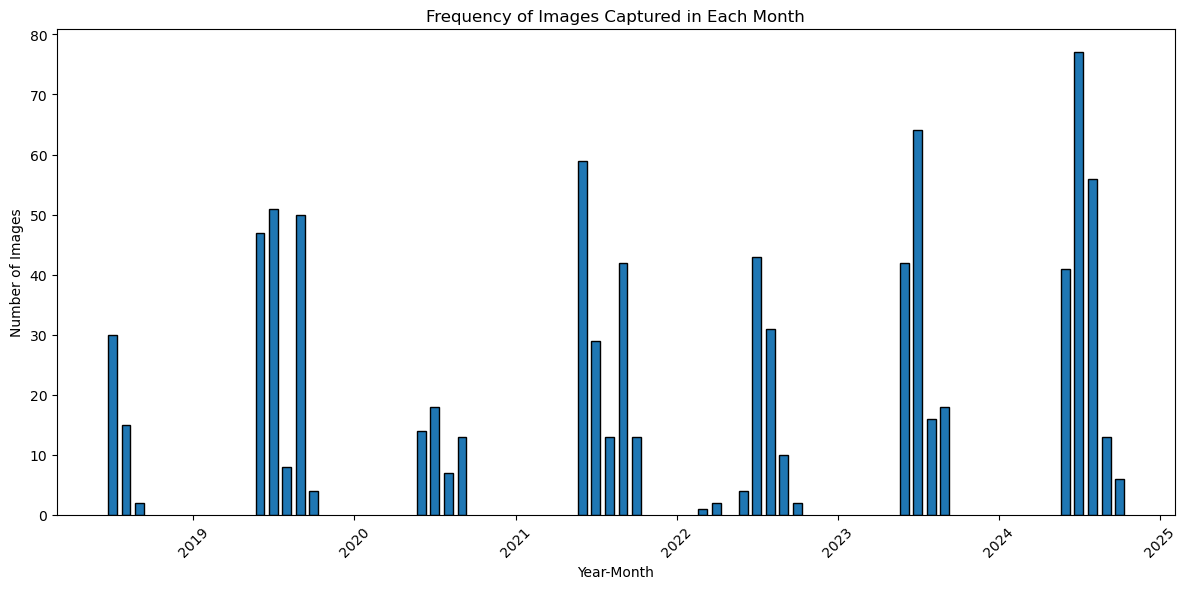

In [32]:
# Extract year and month from image IDs
year_months = [img_id[:6] for img_id in order_imagery]

# Count the frequency of each year-month
year_month_counts = Counter(year_months)

# Convert year-month strings to datetime objects for plotting
year_month_objects = [datetime.strptime(year_month, '%Y%m') for year_month in year_month_counts.keys()]
counts = list(year_month_counts.values())

# Create a histogram
plt.figure(figsize=(12, 6))
plt.bar(year_month_objects, counts, width=20, edgecolor='black')
plt.xlabel('Year-Month')
plt.ylabel('Number of Images')
plt.title('Frequency of Images Captured in Each Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Extract the clearest dates every month

In [36]:
# 1) Group images by year-month-day
monthly_groups = defaultdict(lambda: defaultdict(list))
for image_id, cloud_cover in order_imagery.items():
    # First 8 characters = YYYYMMDD
    date_str = image_id[:8]
    dt = datetime.strptime(date_str, "%Y%m%d")  # parse into a datetime
    year_month = dt.strftime("%Y-%m")           # e.g. "2024-01"
    day = dt.strftime("%d")
    
    monthly_groups[year_month][day].append((image_id, cloud_cover))


# 2) For each year-month, sort by cloud cover and pick up to 3
selected_images = {}
for ym, days in monthly_groups.items():
    # Sort by ascending cloud cover
    for day, images in days.items():
        average_cloud = sum(img[1] for img in images) / len(images)
        monthly_groups[ym][day] = [images,average_cloud]
# 3) Select up to 3 days with the clearest cover for each year-month
for ym, days in monthly_groups.items():
    # Sort days by average cloud cover
    sorted_days = sorted(days.items(), key=lambda x: x[1][1], reverse=True)
    # Select up to 3 days with the clearest cover
    for i in range(5):
        if i < len(sorted_days):
            date = ym + "-" + sorted_days[i][0]
            ids = []
            for id in sorted_days[i][1][0]:
                ids.append(id[0])
            selected_images[date] = ids
            print(date)
            print(selected_images[date])
    # for day, (images, avg_cloud) in sorted_days[:3]:
    #     selected_images.append()


print("Number of days selected: " + str(len(selected_images)))

2024-10-04
['20241004_204343_99_24f4', '20241004_204341_72_24f4', '20241004_204346_26_24f4', '20241004_204051_81_24f5', '20241004_204054_08_24f5', '20241004_200157_54_24c8']
2024-09-07
['20240907_204812_50_24f4', '20240907_204814_85_24f4']
2024-09-03
['20240903_205347_63_24f3', '20240903_205345_27_24f3', '20240903_204700_90_24d7', '20240903_204705_63_24d7', '20240903_204703_27_24d7']
2024-09-11
['20240911_204706_57_241c', '20240911_204702_89_241c', '20240911_204704_73_241c', '20240911_195320_32_24ce', '20240911_195318_18_24ce', '20240911_195744_00_24bf']
2024-08-15
['20240815_204359_07_24f5', '20240815_204356_70_24f5', '20240815_204401_43_24f5', '20240815_195928_67_24b3', '20240815_195926_45_24b3', '20240815_195930_89_24b3', '20240815_205909_10_2438', '20240815_205905_42_2438', '20240815_205724_19_24a4', '20240815_205907_26_2438', '20240815_205722_35_24a4']
2024-08-08
['20240808_195829_38_24ab', '20240808_195827_18_24ab', '20240808_200037_05_24a7', '20240808_200039_31_24a7']
2024-08-05

## Select the images with the most similar tides

In [38]:
tide_csv = "tides/Tuktoyaktuk_tides.csv"
target_tide=0.0
max_images=1


# 1) Load tide data
tide_df = pd.read_csv(tide_csv)
# Ensure columns exist
required_cols = {"dates", "tide"}

# 2) Parse datetime from CSV's date & time
tide_df["datetime"] = tide_df["dates"].apply(parser.parse)

tide_df.set_index("datetime", inplace=True)

# Create a dictionary {datetime: tide_height} for fast lookup
tide_dict = tide_df["tide"].to_dict()


For 300 images this step will take about 10 min

In [39]:
image_ids = list(order_imagery.keys())

# 3) For each image ID, parse date/time, look up tide, store by month
monthly_groups = defaultdict(list)
i = 1
for image_id in image_ids:

    # Extract date/time from image ID
    # first 8 chars: YYYYMMDD, next 6 chars: HHMMSS
    date_str = image_id[:8]
    time_str = image_id[9:15]
    
    try:
        dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
        dt = dt.replace(tzinfo=pytz.UTC)  # Make datetime object timezone-aware

    except ValueError:
        # If the image ID doesn't match the expected format, skip or handle differently
        print("Wrong Format")
        continue
    if dt > datetime(2025, 1, 1, tzinfo=pytz.UTC):
        continue
    closest_time = min(tide_dict.keys(), key=lambda t: abs(t - dt))
    tide_height = tide_dict[closest_time]

    diff = abs(tide_height - target_tide)
    print(f" -{i}/{str(len(image_ids))}- {image_id}: time={dt}, closest time={closest_time}, tide={tide_height:.2f}, difference={diff:.2f}")
    i += 1
    # Group by month (YYYY-MM)
    year_month = dt.strftime("%Y-%m")
    monthly_groups[year_month].append((image_id, tide_height, diff))


print("selecting images")
# 4) Select up to `max_images` images with the smallest difference per month
selected = []
for ym, entries in monthly_groups.items():
    # Sort by difference from target
    entries_sorted = sorted(entries, key=lambda x: x[2])  # x[2] is diff
    # Take first N
    top_n = entries_sorted[:max_images]
    selected.extend(top_n)

print("Selected images closest to 2.0m tide (max 3 per month):")
for (img_id, tide_val, diff) in selected:
    print(f" - {img_id}: tide={tide_val:.2f}, difference={diff:.2f}")

print(f"Selected: {len(selected)} images for order")


 -1/841- 20241004_204343_99_24f4: time=2024-10-04 20:43:43+00:00, closest time=2024-10-04 20:45:00+00:00, tide=-0.02, difference=0.02
 -2/841- 20241004_204341_72_24f4: time=2024-10-04 20:43:41+00:00, closest time=2024-10-04 20:45:00+00:00, tide=-0.02, difference=0.02
 -3/841- 20241004_204346_26_24f4: time=2024-10-04 20:43:46+00:00, closest time=2024-10-04 20:45:00+00:00, tide=-0.02, difference=0.02
 -4/841- 20241004_204051_81_24f5: time=2024-10-04 20:40:51+00:00, closest time=2024-10-04 20:45:00+00:00, tide=-0.02, difference=0.02
 -5/841- 20241004_204054_08_24f5: time=2024-10-04 20:40:54+00:00, closest time=2024-10-04 20:45:00+00:00, tide=-0.02, difference=0.02
 -6/841- 20241004_200157_54_24c8: time=2024-10-04 20:01:57+00:00, closest time=2024-10-04 20:00:00+00:00, tide=-0.08, difference=0.08
 -7/841- 20240911_204706_57_241c: time=2024-09-11 20:47:06+00:00, closest time=2024-09-11 20:45:00+00:00, tide=0.00, difference=0.00
 -8/841- 20240911_204702_89_241c: time=2024-09-11 20:47:02+00:0

## Ordering

Create a function to place Planet orders given a json request and the function that creates the request given an array of IDs and an order name

In [ ]:
# set content type to json
headers = {'content-type': 'application/json'}
orders_url = 'https://api.planet.com/compute/ops/orders/v2' 


def place_order(request, auth):
    response = requests.post(orders_url, data=json.dumps(request), auth=auth, headers=headers)
    print(response)
    order_id = response.json()['id']
    print(order_id) 
    return order_id


def assemble_order(item_ids, name):
    request = {  
        "name":name,
        "products":[
            {  
                "item_ids":item_ids,
                "item_type":"PSScene",
                "product_bundle":"analytic_udm2"
            }
        ],
        "tools":[
            {  
                "clip":{  
                    "aoi":geom_all
                }
            },
            {  
                "composite":{  
                    "group_by":"strip_id"
                }
            }
        ]
    }
    return request



Now we can order all the scenes at once, decide between the tide based selection or the cloud based selection

In [ ]:
order_ids = []

# Iterate over each chunk and place the order
for date, ids in selected.items():
    order_name = f"Saanich_Peninsula_1_{date}"
    request = assemble_order(ids, order_name)
    order = place_order(request, session.auth)
    order_ids.append(order)

# Print all order IDs
print("Order IDs:", order_ids)

In [ ]:
len(order_ids)

given the array of order IDs, download all of your orders to the specified folder. The orders first need to complete which can take 15 min for small orders or up to a couple hours for many large ones

In [ ]:
save_directory = r'D:\ps_imagery\Saanich_Peninsula'


def download_results(results):
    results_urls = [r['location'] for r in results]
    results_names = [r['name'] for r in results]
    print('{} items to download'.format(len(results_urls)))
    
    for url, name in zip(results_urls, results_names):
        path = pathlib.Path(os.path.join(save_directory, name))
        print('downloading {} to {}'.format(name, path))
        r = requests.get(url, allow_redirects=True)
        path.parent.mkdir(parents=True, exist_ok=True)
        open(path, 'wb').write(r.content)

def get_results(order_id):

    r = requests.get(order_url, auth=session.auth)
    response = r.json()
    return response['_links']['results']


for id in order_ids:
    folder_path = os.path.join(save_directory, id)
    if os.path.isdir(folder_path):
        #print(f"Folder {folder_path} already exists, skipping download.")
        continue

    order_url = orders_url + "/" + id
    r = requests.get(order_url, auth=session.auth)
    response = r.json()
    # print(response)
    state = response['state']
    if state == "success" or state == "partial":
        results = get_results(id)
        download_results(results)
    elif state == "failed":
        print(f"Order {id} failed with state {state}")
    elif state == "running":
        print(f"Order {id} still running")
    else:
        print(f"Order {id} in state {state}")

Now that we have downloaded all of the imagery we need to restructure the file structure to fit what CoastSat is expecting. We are basically extracting the json and xml files while renaming the composite files.

In [ ]:
import os
import shutil
import argparse
import shutil

suffix = "composite.tif"
folder = r"D:\ps_imagery\Saanich_Peninsula"
output_folder = r"D:\ps_imagery\temp"

matching_files = []

for dirpath, _, filenames in os.walk(folder):
    for filename in filenames:
        if filename.endswith(suffix):
            matching_files.append(os.path.join(dirpath, filename))

if not matching_files:
    print("No files found with the suffix:", suffix)

for file_path in matching_files:
    file = file_path.split("/")[-1]
    file_id = file.split("_composite")[0]

    file_folder = folder+file_path.split("/")[-2]

    date = file.split("_")[0]
    strip_id = file.split("_")[2]

   
    xml_file = None
    for f in os.listdir(file_folder):
        if f.endswith(".json") and not f.endswith("composite_metadata.json"):
            json_file = file_folder + "/" + f
            
            with open(json_file, 'r') as json_file_data:
                data = json.load(json_file_data)
            
            # Check if the key 'stripID' exists in the JSON data
            if 'properties' in data:
                actual_strip_id = data['properties']['strip_id']
                acquired = data['properties']['acquired']

                if actual_strip_id == strip_id:
                    prefix = f.split("metadata")[0]
                    xml_file = file_folder + "/" + prefix + "3B_AnalyticMS_metadata_clip.xml"
    
    file = file_folder + "/" + file
    new_file = output_folder + prefix[:15]+"_"+ strip_id + "_AnalyticMS_clip.tif"
    print(file)
    print(new_file)

    udm_file = file_folder + "/" + file_id + "_composite_udm2.tif"
    new_udm = output_folder + prefix[:15]+"_"+ strip_id + "_AnalyticMS_udm2_clip.tif"


    json_file = file_folder + "/" +file_id + "_composite_metadata.json"
    new_json = output_folder + prefix[:15]+"_"+ strip_id + "_metadata.json"
    new_xml = output_folder + prefix[:15]+"_"+ strip_id + "_metadata_clip.xml"


    if os.path.exists(file):
        if os.path.exists(udm_file):
            if os.path.exists(json_file):
                if os.path.exists(xml_file):
                    shutil.copy2(udm_file, new_udm)
                    shutil.copy2(xml_file, new_xml)
                    shutil.copy2(json_file, new_json)
                    shutil.copy2(file, new_file)
                else:
                    print("xml file does not exist.")
            else:
                print("json file does not exist.")
        else:
            print("udm file does not exist.")
    else:
        print("main file does not exist.")
